# eigenfaces: face recognition via pca

## introduction

a face image of 64×64 pixels lives in a 4096-dimensional space — one dimension per pixel. that's enormous. but real faces don't fill that space randomly: they share structure (two eyes, a nose, a mouth, similar proportions). this means faces actually cluster in a much smaller **subspace**.

**eigenfaces** is the technique that finds that subspace. it uses **Principal Component Analysis (PCA)** to discover the directions of maximum variance across a set of face images. these directions, when reshaped back into images, look like ghostly face-like patterns — the eigenfaces.

once we have this subspace, we can:
- represent any face as a small vector of weights (dimensionality reduction)
- reconstruct faces from those weights (lossy compression)
- recognize faces by comparing their weight vectors (nearest neighbor)

the math behind all of this is **eigenvectors and eigenvalues** of the covariance matrix of our data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

## 1. dataset

we use the **olivetti faces** dataset (originally from AT&T labs): 400 grayscale images of 40 people, 10 images per person. each image is 64×64 pixels, pre-aligned and normalized to [0, 1].

this is an ideal dataset for eigenfaces: small enough to compute quickly, large enough to be interesting, and each person has multiple images with slight variation in expression and lighting.

images: (400, 4096)
labels: (400,)
unique people: 40
images per person: 10


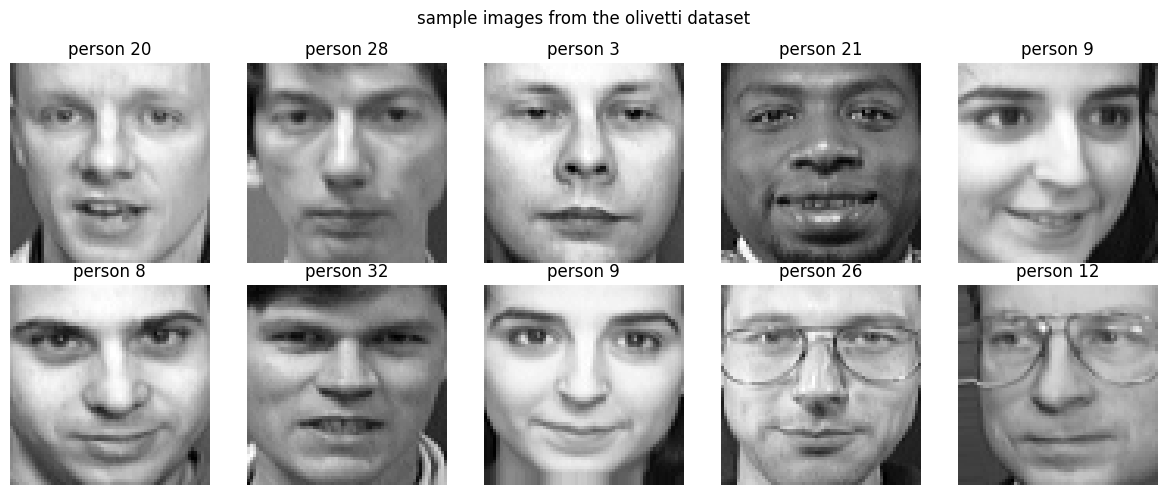

In [3]:
data = fetch_olivetti_faces(shuffle=True, random_state=42)

X = data.data        # (400, 4096) — each row is a flattened image
y = data.target      # (400,)      — person id 0..39
images = data.images # (400, 64, 64)

print("images:", X.shape)
print("labels:", y.shape)
print("unique people:", len(np.unique(y)))
print("images per person:", np.sum(y == 0))

# show a sample
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"person {y[i]}")
    ax.axis("off")
plt.suptitle("sample images from the olivetti dataset")
plt.tight_layout()
plt.show()

## 2. data preprocessing

before applying PCA we need to **mean-center** the data. this means computing the average face across all training images and subtracting it from every image.

why? PCA finds directions of maximum *variance* (spread) around the center of the data. if we don't center first, the first principal component just points toward the mean — not toward the most discriminative direction.

the mean face itself is also interesting to visualize: it shows what a "generic" face looks like in this dataset.

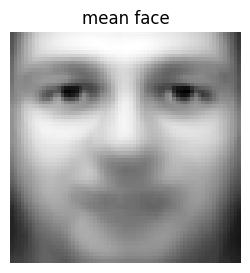

training set: (320, 4096)
test set:     (80, 4096)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# compute mean face from training data only (never use test data to fit)
mean_face = X_train.mean(axis=0)  # shape: (4096,)

# mean-center
X_train_centered = X_train - mean_face
X_test_centered  = X_test  - mean_face

# visualize the mean face
plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(64, 64), cmap="gray")
plt.title("mean face")
plt.axis("off")
plt.show()

print("training set:", X_train.shape)
print("test set:    ", X_test.shape)

## 3. the math: pca from scratch

PCA on a dataset $X$ (n samples × d features, already mean-centered) works as follows:

1. form the covariance matrix $C = \frac{1}{n} X^T X$
2. compute its eigenvectors and eigenvalues
3. sort eigenvectors by descending eigenvalue
4. the top $k$ eigenvectors are the principal components

**the efficient trick:** $X^T X$ is $d \times d$ (4096×4096 here) — large but tractable. the alternative $X X^T$ is $n \times n$ (320×320) — actually smaller in this case, and its eigenvectors can be mapped back to those of $X^T X$. we use whichever is smaller.

since $n < d$ here (320 training samples, 4096 dimensions), we compute $X X^T$ and recover the eigenvectors of the covariance matrix from it.

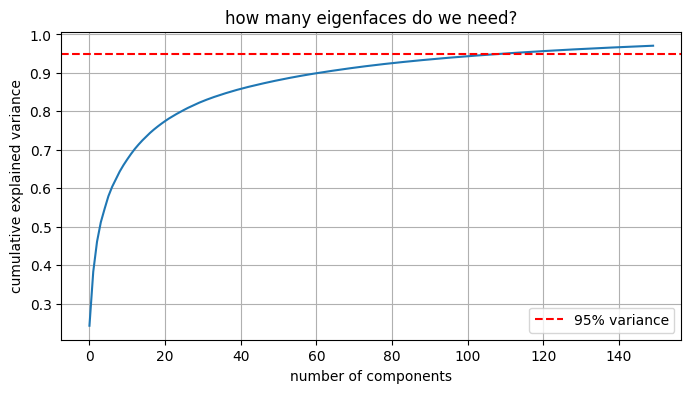

111 eigenfaces explain 95% of the variance


In [5]:
n = X_train_centered.shape[0]  # 320

# compute the compact covariance matrix (n x n instead of d x d)
C_compact = (X_train_centered @ X_train_centered.T) / n  # (320, 320)

# eigendecomposition — eigh is for symmetric matrices (faster, more stable)
eigenvalues, eigenvectors_compact = np.linalg.eigh(C_compact)

# sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors_compact = eigenvectors_compact[:, idx]

# map compact eigenvectors back to the full d-dimensional space
# if C_compact * v = lambda * v, then (X^T X) * (X^T v) = lambda * (X^T v)
eigenvectors_full = X_train_centered.T @ eigenvectors_compact  # (4096, 320)

# normalize each eigenvector to unit length
norms = np.linalg.norm(eigenvectors_full, axis=0, keepdims=True)
eigenvectors_full = eigenvectors_full / norms  # (4096, 320)

# explained variance ratio
total_variance = eigenvalues.sum()
explained_ratio = np.cumsum(eigenvalues) / total_variance

plt.figure(figsize=(8, 4))
plt.plot(explained_ratio[:150])
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.title("how many eigenfaces do we need?")
plt.legend()
plt.grid(True)
plt.show()

k95 = np.searchsorted(explained_ratio, 0.95) + 1
print(f"{k95} eigenfaces explain 95% of the variance")

## 4. eigenfaces

each eigenvector has 4096 components — the same length as a flattened image. when we reshape it into 64×64, we get an **eigenface**: a face-like pattern that encodes a direction of maximum variation across all training faces.

- the first eigenfaces capture the broadest differences (overall lighting, face outline)
- later eigenfaces capture finer details (eyes, wrinkles, specific features)

we also verify our manual result against sklearn's PCA — they should produce the same eigenfaces (up to sign).

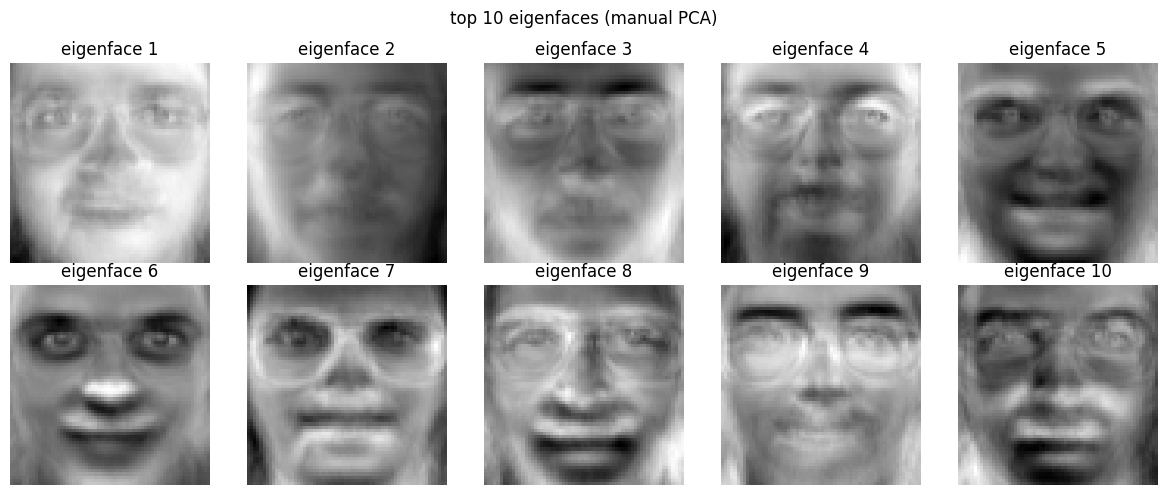

alignment with sklearn (should be ~1.0): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
from sklearn.decomposition import PCA

k = 100  # number of eigenfaces to use

# our manual eigenfaces (top k)
eigenfaces_manual = eigenvectors_full[:, :k].T  # (k, 4096)

# sklearn for comparison
pca_sk = PCA(n_components=k, svd_solver="randomized", whiten=False)
pca_sk.fit(X_train_centered)

# visualize top 10 eigenfaces (manual)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces_manual[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"eigenface {i+1}")
    ax.axis("off")
plt.suptitle("top 10 eigenfaces (manual PCA)")
plt.tight_layout()
plt.show()

# verify: dot product between manual and sklearn eigenvectors should be ~1 (up to sign)
dots = np.abs(np.diag(eigenfaces_manual[:10] @ pca_sk.components_[:10].T))
print("alignment with sklearn (should be ~1.0):", np.round(dots, 3))

## 5. face reconstruction

any face can be approximately reconstructed from $k$ eigenfaces:

$$\hat{x} = \bar{x} + \sum_{i=1}^{k} w_i \cdot u_i$$

where $w_i = (x - \bar{x}) \cdot u_i$ is the weight (projection) onto eigenface $i$, and $u_i$ is eigenface $i$.

with few eigenfaces the reconstruction is blurry — only the coarsest structure is captured. as $k$ grows, finer details appear. the reconstruction error (MSE) quantifies this.

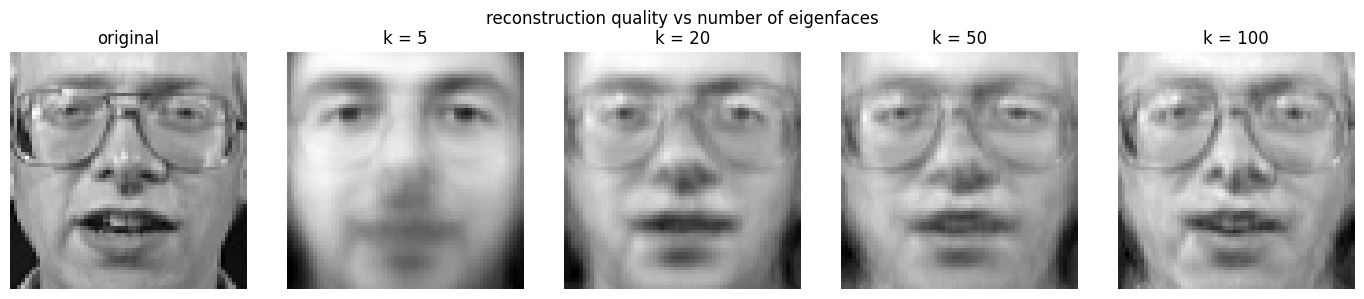

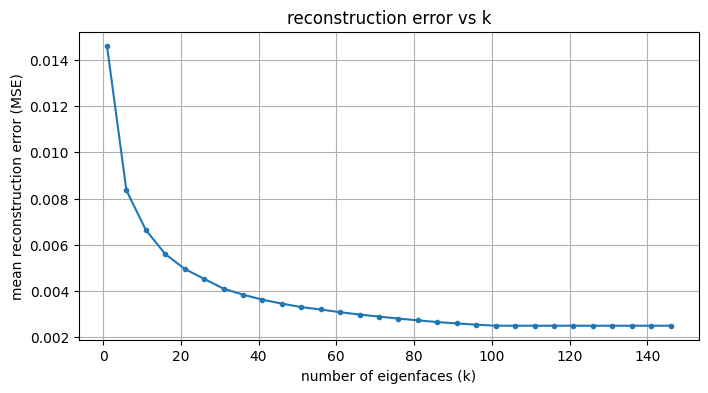

In [7]:
def project(X_centered, eigenfaces_k):
    """project centered images into eigenspace. returns weights (n, k)."""
    return X_centered @ eigenfaces_k.T

def reconstruct(weights, eigenfaces_k, mean_face):
    """reconstruct images from weights."""
    return weights @ eigenfaces_k + mean_face

def mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2, axis=1)

# show reconstruction at different k values for one test image
sample = X_test_centered[[0]]
k_values = [5, 20, 50, 100]

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(14, 3))
axes[0].imshow(X_test[0].reshape(64, 64), cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")

for ax, k_val in zip(axes[1:], k_values):
    ef_k = eigenfaces_manual[:k_val]
    w = project(sample, ef_k)
    rec = reconstruct(w, ef_k, mean_face)
    ax.imshow(rec.reshape(64, 64), cmap="gray")
    ax.set_title(f"k = {k_val}")
    ax.axis("off")

plt.suptitle("reconstruction quality vs number of eigenfaces")
plt.tight_layout()
plt.show()

# reconstruction error curve
errors = []
k_range = list(range(1, 151, 5))
for k_val in k_range:
    ef_k = eigenfaces_manual[:k_val]
    w = project(X_test_centered, ef_k)
    rec = reconstruct(w, ef_k, mean_face)
    errors.append(mse(X_test, rec).mean())

plt.figure(figsize=(8, 4))
plt.plot(k_range, errors, marker="o", markersize=3)
plt.xlabel("number of eigenfaces (k)")
plt.ylabel("mean reconstruction error (MSE)")
plt.title("reconstruction error vs k")
plt.grid(True)
plt.show()

## 6. face recognition

to recognize a face we:
1. project it into eigenspace: $w = U_k^T (x - \bar{x})$
2. compute the euclidean distance between its weight vector and every training face's weight vector
3. return the identity of the nearest neighbor

faces of the same person cluster together in eigenspace — that's what makes this work. we implement this manually so the geometry is transparent.

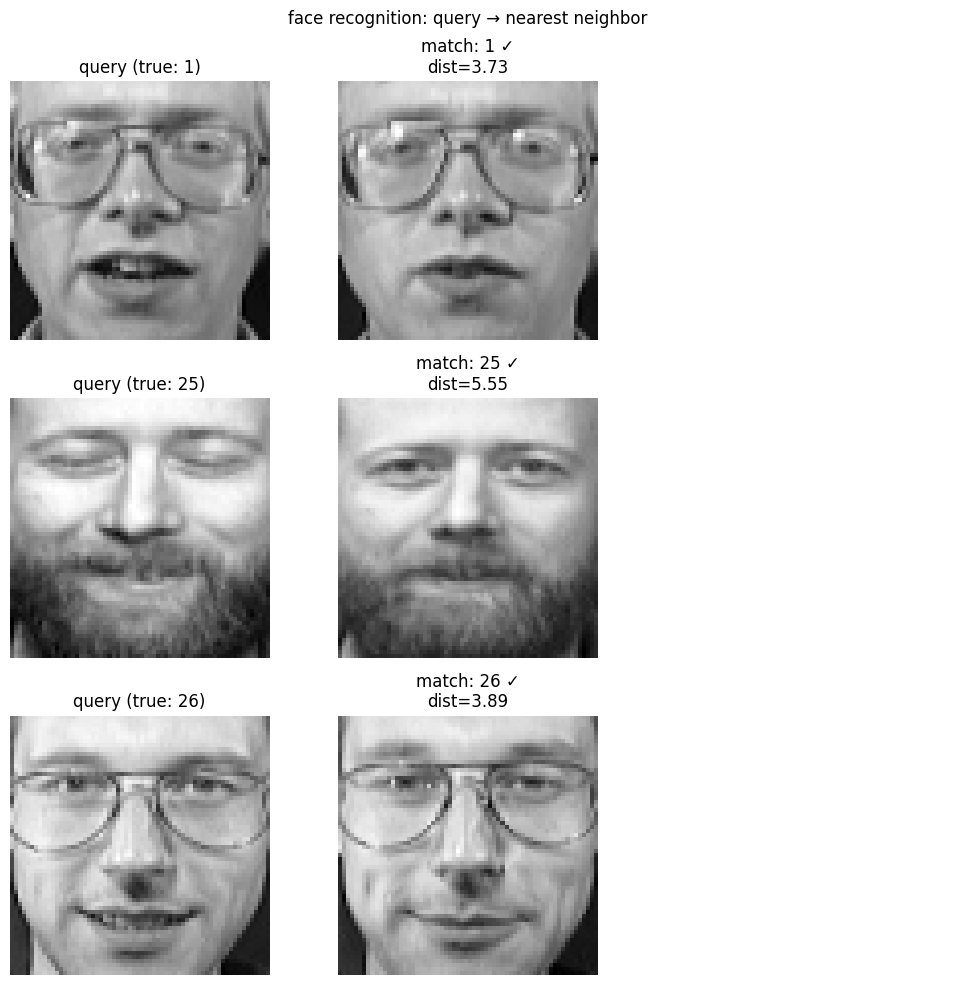

In [8]:
def recognize(query_centered, train_weights, y_train, k, eigenfaces_k):
    """
    query_centered: (1, 4096) mean-centered query image
    returns: (predicted label, distance to nearest neighbor, index in training set)
    """
    q_weight = project(query_centered, eigenfaces_k)             # (1, k)
    distances = np.linalg.norm(train_weights - q_weight, axis=1) # (n_train,)
    nearest_idx = np.argmin(distances)
    return y_train[nearest_idx], distances[nearest_idx], nearest_idx

k = 100
ef_k = eigenfaces_manual[:k]
train_weights = project(X_train_centered, ef_k)  # (320, k)

# test on a few examples
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for row in range(3):
    query_idx = row * 10
    query_img = X_test_centered[[query_idx]]
    pred_label, dist, match_idx = recognize(query_img, train_weights, y_train, k, ef_k)
    true_label = y_test[query_idx]

    axes[row, 0].imshow(X_test[query_idx].reshape(64, 64), cmap="gray")
    axes[row, 0].set_title(f"query (true: {true_label})")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(X_train[match_idx].reshape(64, 64), cmap="gray")
    correct = "✓" if pred_label == true_label else "✗"
    axes[row, 1].set_title(f"match: {pred_label} {correct}\ndist={dist:.2f}")
    axes[row, 1].axis("off")

    axes[row, 2].axis("off")  # spacer

plt.suptitle("face recognition: query → nearest neighbor")
plt.tight_layout()
plt.show()

## 7. unknown face detection

the nearest-neighbor classifier always returns *some* match — even for an image that is completely unlike any training face. to handle this, we add a **distance threshold**: if the nearest neighbor distance exceeds it, we classify the face as "unknown".

the threshold needs to be set based on the distribution of within-class distances in the training data. we visualize that distribution to choose a sensible value.

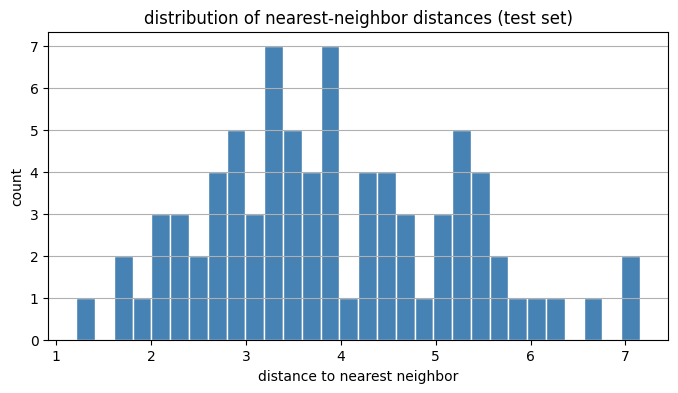

suggested threshold: 6.52
random noise image → predicted: 'unknown', distance: 7.27


In [9]:
# compute distribution of distances for correct matches (same person)
correct_distances = []
for i in range(len(X_test_centered)):
    q_weight = project(X_test_centered[[i]], ef_k)
    distances = np.linalg.norm(train_weights - q_weight, axis=1)
    correct_distances.append(distances.min())

correct_distances = np.array(correct_distances)

plt.figure(figsize=(8, 4))
plt.hist(correct_distances, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("distance to nearest neighbor")
plt.ylabel("count")
plt.title("distribution of nearest-neighbor distances (test set)")
plt.grid(True, axis="y")
plt.show()

# choose a threshold (e.g. mean + 2 std)
threshold = correct_distances.mean() + 2 * correct_distances.std()
print(f"suggested threshold: {threshold:.2f}")

def recognize_with_threshold(query_centered, train_weights, y_train, ef_k, threshold):
    q_weight = project(query_centered, ef_k)
    distances = np.linalg.norm(train_weights - q_weight, axis=1)
    nearest_idx = np.argmin(distances)
    min_dist = distances[nearest_idx]
    if min_dist > threshold:
        return "unknown", min_dist, nearest_idx
    return y_train[nearest_idx], min_dist, nearest_idx

# test with a non-face image (random noise as a stand-in)
rng = np.random.default_rng(0)
fake_face = rng.random((1, 4096))
fake_centered = fake_face - mean_face
label, dist, _ = recognize_with_threshold(fake_centered, train_weights, y_train, ef_k, threshold)
print(f"random noise image → predicted: '{label}', distance: {dist:.2f}")

## 8. evaluation

we now evaluate the full pipeline on the held-out test set and sweep over different values of $k$ to see how recognition accuracy changes.

more eigenfaces = more information preserved = better recognition, up to a point. beyond that, additional components add noise rather than signal.

k=   5  accuracy=0.738
k=  10  accuracy=0.912
k=  20  accuracy=0.938
k=  30  accuracy=0.950
k=  50  accuracy=0.950
k=  75  accuracy=0.950
k= 100  accuracy=0.950
k= 150  accuracy=0.950


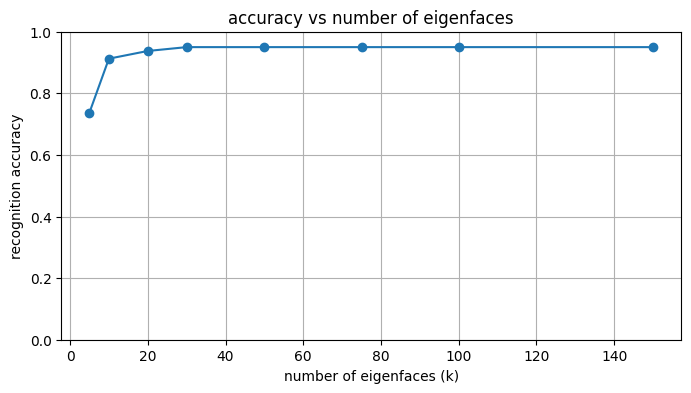

In [10]:
k_values = [5, 10, 20, 30, 50, 75, 100, 150]
accuracies = []

for k_val in k_values:
    ef_k = eigenfaces_manual[:k_val]
    tw = project(X_train_centered, ef_k)

    correct = 0
    for i in range(len(X_test_centered)):
        pred, _, _ = recognize(X_test_centered[[i]], tw, y_train, k_val, ef_k)
        if pred == y_test[i]:
            correct += 1

    acc = correct / len(y_test)
    accuracies.append(acc)
    print(f"k={k_val:4d}  accuracy={acc:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("number of eigenfaces (k)")
plt.ylabel("recognition accuracy")
plt.title("accuracy vs number of eigenfaces")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

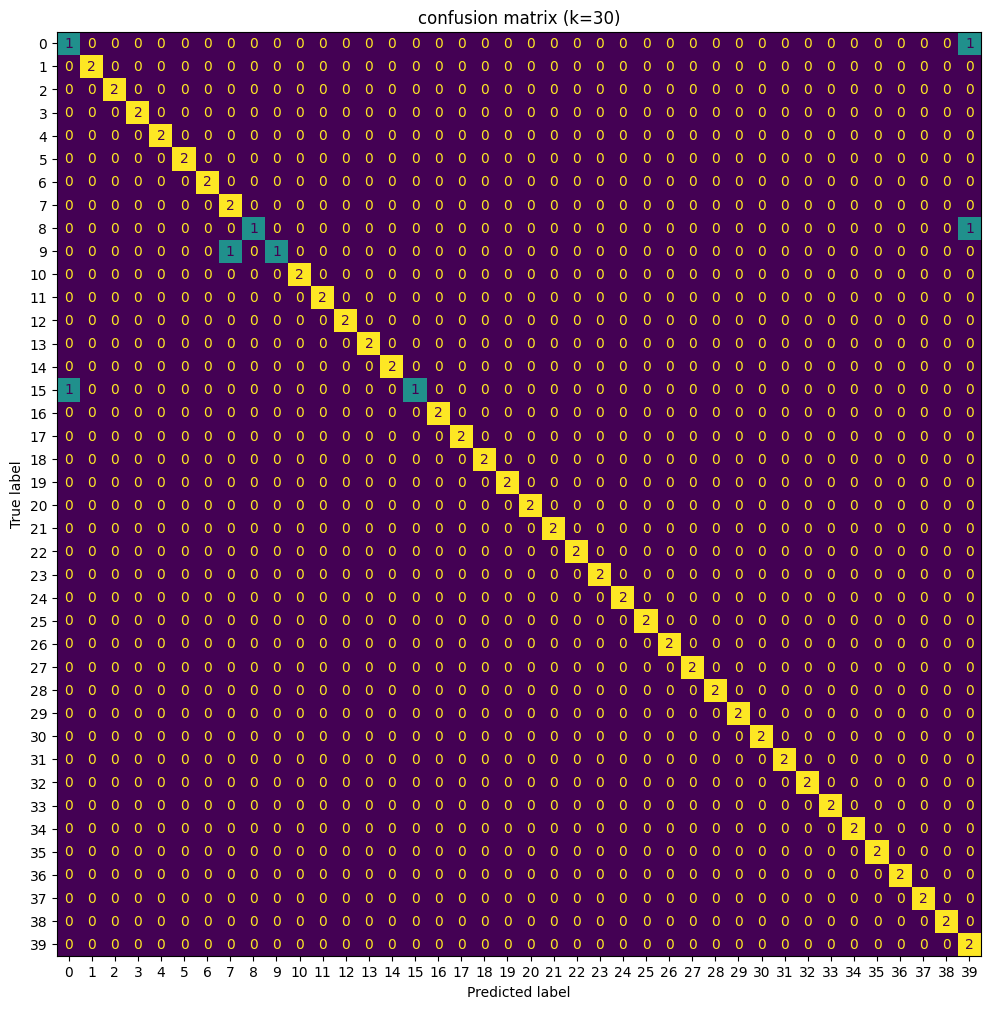

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

k_best = k_values[np.argmax(accuracies)]
ef_k = eigenfaces_manual[:k_best]
tw = project(X_train_centered, ef_k)

y_pred = [recognize(X_test_centered[[i]], tw, y_train, k_best, ef_k)[0]
          for i in range(len(X_test_centered))]

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
plt.title(f"confusion matrix (k={k_best})")
plt.show()

## 9. interactive demo

use the slider to change $k$ and see how reconstruction quality and recognition change in real time.

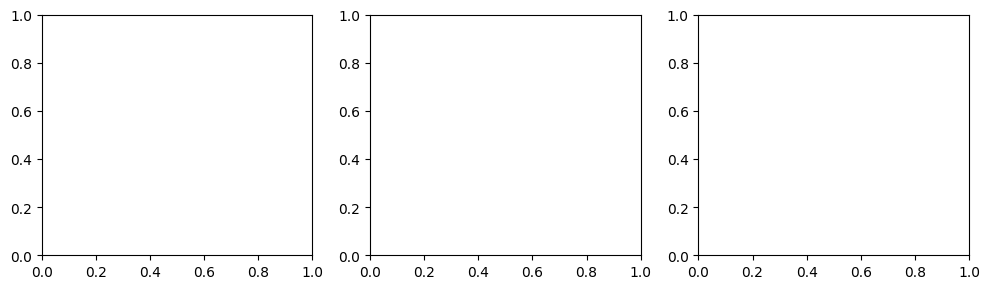

IntSlider(value=50, description='k:', max=150, min=1)

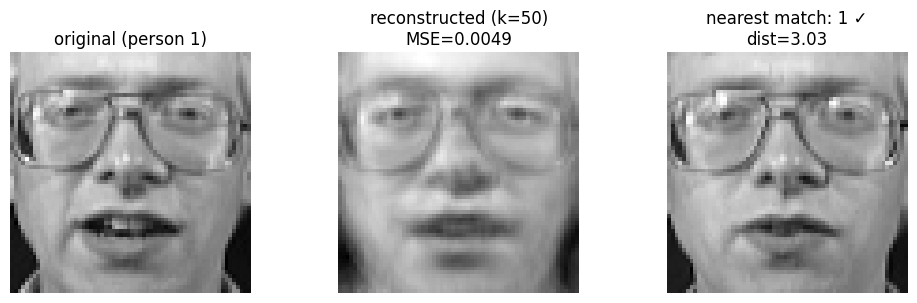

In [12]:
import ipywidgets as widgets
from IPython.display import display

# pick a fixed test image to demo
demo_idx = 0
demo_img = X_test_centered[[demo_idx]]
demo_original = X_test[demo_idx]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
plt.tight_layout()

def update(k=50):
    ef_k = eigenfaces_manual[:k]
    tw = project(X_train_centered, ef_k)

    # reconstruction
    w = project(demo_img, ef_k)
    rec = reconstruct(w, ef_k, mean_face)
    error = np.mean((demo_original - rec) ** 2)

    # recognition
    pred_label, dist, match_idx = recognize(demo_img, tw, y_train, k, ef_k)

    for ax in axes:
        ax.cla()
        ax.axis("off")

    axes[0].imshow(demo_original.reshape(64, 64), cmap="gray")
    axes[0].set_title(f"original (person {y_test[demo_idx]})")

    axes[1].imshow(rec.reshape(64, 64), cmap="gray")
    axes[1].set_title(f"reconstructed (k={k})\nMSE={error:.4f}")

    axes[2].imshow(X_train[match_idx].reshape(64, 64), cmap="gray")
    correct = "✓" if pred_label == y_test[demo_idx] else "✗"
    axes[2].set_title(f"nearest match: {pred_label} {correct}\ndist={dist:.2f}")

    fig.canvas.draw_idle()

slider = widgets.IntSlider(value=50, min=1, max=150, step=1, description="k:")
widgets.interactive_output(update, {"k": slider})
display(slider, fig)